<a href="https://colab.research.google.com/github/mikhelif/sar-subaperture-processor/blob/main/Sub_aperture_ship_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1- Installing the Sub-Aperture Processor :**



In [1]:
!rm -rf /content/sar-subaperture-processor
!git clone https://github.com/mikhelif/sar-subaperture-processor.git
!pip install -r /content/sar-subaperture-processor/requirements.txt
!pip install -e /content/sar-subaperture-processor

Cloning into 'sar-subaperture-processor'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 63 (delta 29), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 44.63 MiB | 15.87 MiB/s, done.
Resolving deltas: 100% (29/29), done.
Obtaining file:///content/sar-subaperture-processor
  Preparing metadata (setup.py) ... done
  Running setup.py develop for sar-subaperture-processor


# **2- Data download :**

A few Stripmap SLC scenes covering active shipping lanes are available on ICEYE's Open Data catalogue. These images can be downloaded using 'wget' or 'curl' here's links to a few of them :
[Scene 1](http://iceye-open-data-catalog.s3.amazonaws.com/data/stripmap/ICEYE_U11K1P_20260129T135033Z_8661749_X53_SM/ICEYE_U11K1P_20260129T135033Z_8661749_X53_SM_SLC.tif)
[Scene 2 ](http://iceye-open-data-catalog.s3.amazonaws.com/data/stripmap/ICEYE_U110GN_20260129T135042Z_8661749_X53_SM/ICEYE_U110GN_20260129T135042Z_8661749_X53_SM_SLC.tif)
[Scne 3](http://iceye-open-data-catalog.s3.amazonaws.com/data/stripmap/ICEYE_W22P0J_20260204T034902Z_8730857_X61_SM/ICEYE_W22P0J_20260204T034902Z_8730857_X61_SM_SLC.tif)

In [ ]:
!wget http://iceye-open-data-catalog.s3.amazonaws.com/data/stripmap/ICEYE_U11K1P_20260129T135033Z_8661749_X53_SM/ICEYE_U11K1P_20260129T135033Z_8661749_X53_SM_SLC.tif

These scenes are large (~10-12 GB each). I recommend creating a spatial subset using ESA's SNAP.
Once the subset is exported, you can upload it to Google Drive and mount your drive in the notebook or processlocally:


# **3- Import dependencies and mount drive**

In [2]:
import numpy as np
import sys
sys.path.insert(0, '/content/sar-subaperture-processor')
from sar_subaperture_processor import SARSubapertureProcessor
from pathlib import Path
import rasterio
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter
from google.colab import drive #optional
drive.mount('/content/drive')

Mounted at /content/drive


# **4- Initialize the sub-aperture processor :**
Set the path to your SLC file and output directory, then initialize the processor and generate 2 sub-aperture images.
I noticed that for this application a rectangular filter produce better coherence contrast, at the cost of higher
azimuth sidelobes around bright targets.

In [3]:
slc_path='/content/drive/MyDrive/Colab Notebooks/iceye/20260129.tif'
output_dir="/content/drive/MyDrive/Colab Notebooks/iceye"

proc = SARSubapertureProcessor(slc_path, structure="AP") #Iceye SLC comes with amplitude and phase bands
proc.read_slc()
proc.generate_subapertures(win_frac=0.5, step_frac=0.5,filter='rectangular')

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Setting both `win_frac` and `step_frac` to `0.5` should in theory split the Doppler spectrum into two non-overlapping halves con either side of the Doppler centroid. But the DC
of this image is approximately -137 Hz, meaning the spectrum is not perfectly centered
at 0. But I have found this to have little impact on the results. Currently working on a deramping function to fix this issue.



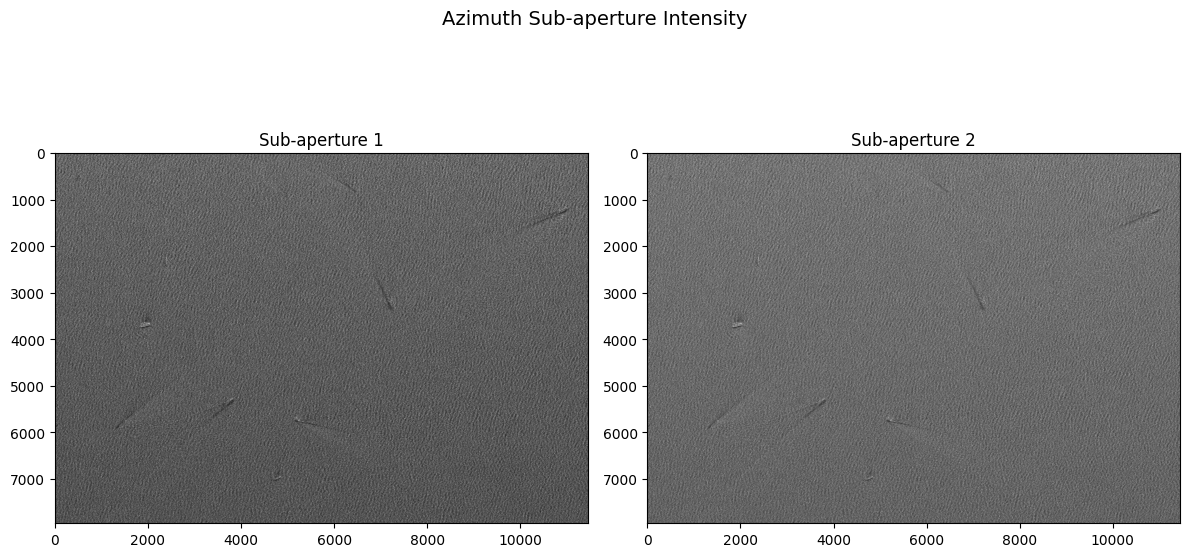

In [4]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(np.abs(proc.subapertures[0]), cmap='gray', vmax=np.percentile(np.abs(proc.subapertures[0]), 99))
axes[0].set_title('Sub-aperture 1')
axes[1].imshow(np.abs(proc.subapertures[1]), cmap='gray', vmax=np.percentile(np.abs(proc.subapertures[1]), 99))
axes[1].set_title('Sub-aperture 2')
fig.suptitle('Azimuth Sub-aperture Intensity', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# **5- Coherence estimation**
The two sub-apertures are then used to compute a coherence map.

In [5]:
def compute_coherence(sub1, sub2, kernel_az=3, kernel_rg=11):

    def boxcar(arr, kaz, krg):
        return uniform_filter(arr, size=(kaz, krg), mode='reflect')

    def boxcar_complex(arr, kaz, krg):
        return boxcar(arr.real, kaz, krg) + 1j * boxcar(arr.imag, kaz, krg)

    cross     = boxcar_complex(sub1 * np.conj(sub2), kernel_az, kernel_rg)
    power1    = boxcar(np.abs(sub1) ** 2, kernel_az, kernel_rg)
    power2    = boxcar(np.abs(sub2) ** 2, kernel_az, kernel_rg)
    denom     = np.sqrt(power1 * power2)
    coherence = np.where(denom > 0, np.abs(cross) / denom, 0.0).astype(np.float32)

    return coherence

In [6]:
coh = compute_coherence(proc.subapertures[0], proc.subapertures[1])

# **6- Azimuth Misregistration (optional)**
A slight azimuth misregistration can improve the contrast between ships and sea clutter. This technique was introduced by Song et al. (2026) as part of a single-channel SAR MTI algorithm, but I have found that it also improve ships' visibility the sea background particularly at lowincidence angles.

In [7]:
def apply_azimuth_misregistration(subs, idx1=0, idx2=1, mx_pixels=3):
    sub1 = subs[idx1].astype(np.complex64)
    sub2 = subs[idx2].astype(np.complex64)

    sub2_shifted = np.zeros_like(sub2)
    if mx_pixels > 0:
        sub2_shifted[mx_pixels:, :] = sub2[:-mx_pixels, :]
    elif mx_pixels < 0:
        sub2_shifted[:mx_pixels, :] = sub2[-mx_pixels:, :]
    else:
        sub2_shifted = sub2.copy()

    return sub1, sub2_shifted

In [8]:
shifted_subs=apply_azimuth_misregistration(proc.subapertures)

/tmp/ipykernel_5759/1542813478.py:13: RuntimeWarning: invalid value encountered in divide
  coherence = np.where(denom > 0, np.abs(cross) / denom, 0.0).astype(np.float32)


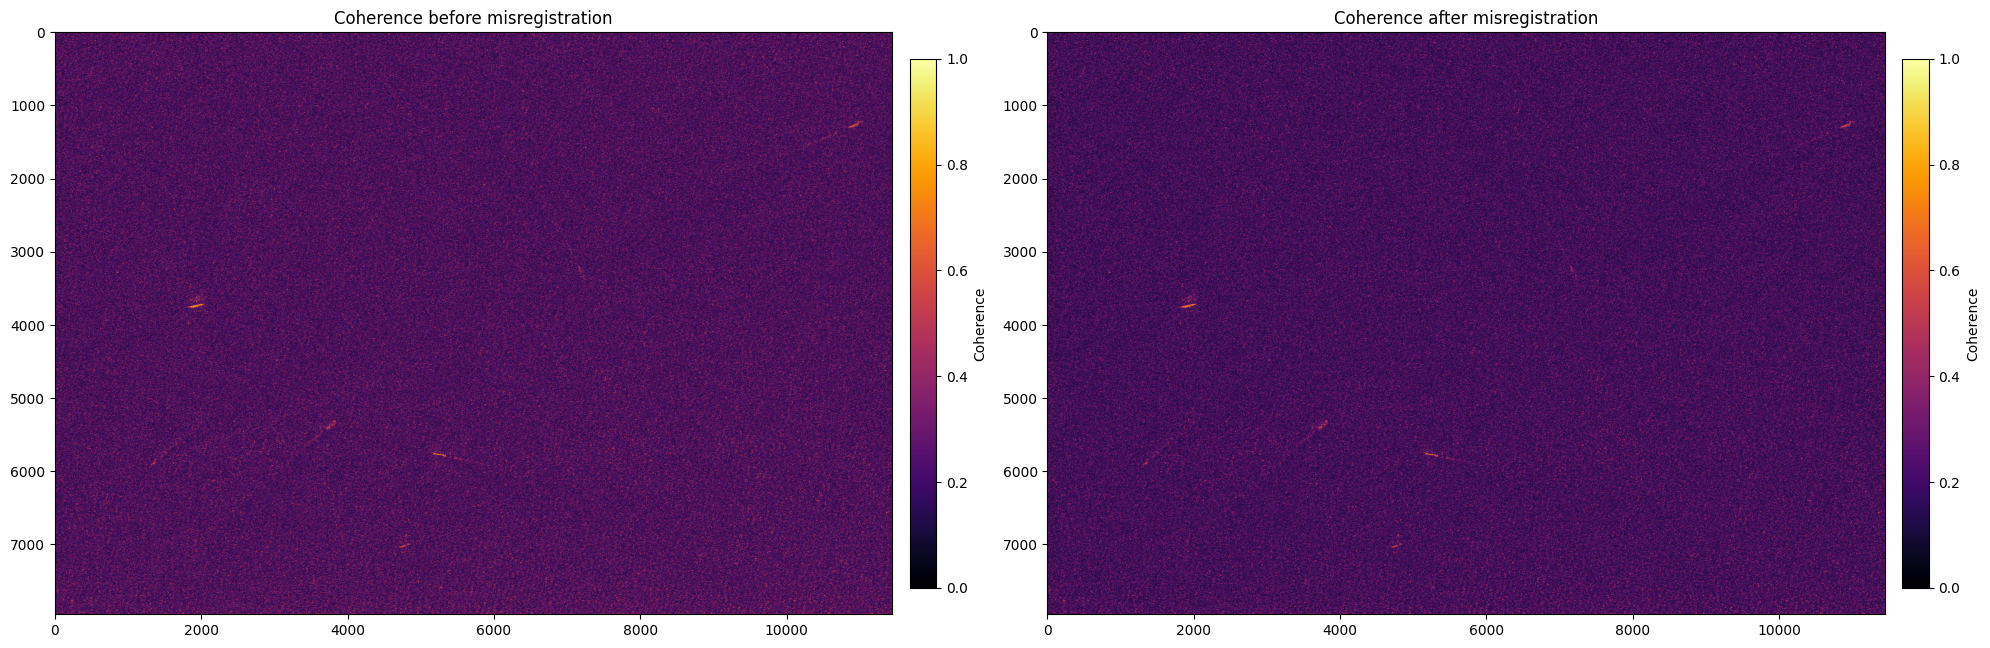

In [9]:
coh_shifted  = compute_coherence(shifted_subs[0], shifted_subs[1])

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
im0 = axes[0].imshow(coh, cmap='inferno', vmin=0, vmax=1)
axes[0].set_title('Coherence before misregistration')
plt.colorbar(im0, ax=axes[0], label='Coherence', fraction=0.03, pad=0.02)

im1 = axes[1].imshow(coh_shifted, cmap='inferno', vmin=0, vmax=1)
axes[1].set_title('Coherence after misregistration')
plt.colorbar(im1, ax=axes[1], label='Coherence', fraction=0.03, pad=0.02)

plt.tight_layout()
plt.show()

# **7- Export files**

In [ ]:
proc.save_subs_intensity(output_dir, prefix="sub", scale="linear")

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:377: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


In [ ]:
from pathlib import Path
import rasterio
def save_coherence(coh, out_dir, proc, filename="coherence.tif"):
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    with rasterio.open(
        f"{out_dir}/{filename}",
        "w",
        driver="GTiff",
        height=coh.shape[0],
        width=coh.shape[1],
        count=1,
        dtype='float32',
        transform=proc.transform,
        crs=proc.crs
    ) as dst:
        dst.write(coh, 1)

save_coherence(coh, output_dir, proc)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:377: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(
